<a href="https://colab.research.google.com/github/sergiodanier1/acuacode/blob/main/IA_pokemon_generativa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Conectar con el drive



In [ ]:
import os
from google.colab import drive

# Si el directorio /content/drive existe, lo eliminamos para montar limpio
if os.path.exists('/content/drive'):
    !rm -rf /content/drive

# Ahora montamos Drive
drive.mount('/content/drive')

rm: cannot remove '/content/drive/MyDrive': Operation canceled
rm: cannot remove '/content/drive/.shortcut-targets-by-id': Operation canceled
rm: cannot remove '/content/drive/.Trash-0': Directory not empty
rm: cannot remove '/content/drive/.Encrypted/MyDrive': Operation canceled
rm: cannot remove '/content/drive/.Encrypted/.shortcut-targets-by-id': Operation canceled
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dependencias

In [ ]:
!pip install tqdm matplotlib pillow pandas numpy torch torchvision -q
!pip install -q tensorflow pandas scikit-learn

2. Cargar librerías

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

3 Rutas

In [ ]:
BASE_DIR = "/content/drive/MyDrive/mi_proyecto_pokemon"

CARPETA_IMAGENES = os.path.join(BASE_DIR, "datos_procesados")

ARCHIVO_CSV = os.path.join(
    BASE_DIR,
    "metadata",
    "etiquetas_pokemon.csv"
)

4 Leer el CSV

In [ ]:
metadata = pd.read_csv(ARCHIVO_CSV)
metadata.head()

,nombre_archivo,postura_bipedo,postura_cuadrupedo,postura_serpentiforme,postura_volador,ojos_circulares,ojos_rasgados,sin_ojos,delantera_brazo,delantera_pata,delantera_ala,sin_delantera,trasera_pata_animal,trasera_pata_ave,sin_trasera,cola_larga_flexible,cola_maza,sin_cola,nivel_evolutivo
0,001.npy,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,1
1,002.npy,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,2
2,003.npy,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,3
3,004.npy,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,1
4,005.npy,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,2


5. cargar imagenes

In [ ]:
archivos = sorted(glob.glob(os.path.join(CARPETA_IMAGENES,"*.npy")))

imagenes = []

for archivo in archivos:

    img = np.load(archivo)

    img = img.astype(np.float32)

    if img.max()>1:
        img = img/255.0

    imagenes.append(img)

imagenes = np.array(imagenes)

print(imagenes.shape)

(350, 64, 64, 3)


6. División entrenamiento

In [ ]:
x_train, x_test = train_test_split(
    imagenes,
    test_size=0.1,
    random_state=42
)

7. Dimensiones

In [ ]:
alto = imagenes.shape[1]
ancho = imagenes.shape[2]
canales = imagenes.shape[3]

latent_dim = 128

8. Encoder

In [ ]:
encoder_inputs = tf.keras.Input(shape=(alto,ancho,canales))

x = layers.Conv2D(32,3,strides=2,padding="same",activation="relu")(encoder_inputs)
x = layers.Conv2D(64,3,strides=2,padding="same",activation="relu")(x)
x = layers.Conv2D(128,3,strides=2,padding="same",activation="relu")(x)

shape_before = tf.keras.backend.int_shape(x)

x = layers.Flatten()(x)

z = layers.Dense(latent_dim)(x)

encoder = tf.keras.Model(encoder_inputs,z)

encoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,141,952 (4.36 MB)

 Trainable params: 1,141,952 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

9. Decoder

In [ ]:
decoder_inputs = tf.keras.Input(shape=(latent_dim,))

unidades = int(np.prod(shape_before[1:]))

x = layers.Dense(unidades)(decoder_inputs)

x = layers.Reshape(shape_before[1:])(x)

x = layers.Conv2DTranspose(
    128,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

x = layers.Conv2DTranspose(
    64,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

x = layers.Conv2DTranspose(
    32,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

decoder_outputs = layers.Conv2D(
    canales,
    3,
    padding="same",
    activation="sigmoid"
)(x)

decoder = tf.keras.Model(decoder_inputs, decoder_outputs)

10. Autoencoder

In [ ]:
inputs = tf.keras.Input(shape=(alto,ancho,canales))

latent = encoder(inputs)

outputs = decoder(latent)

autoencoder = tf.keras.Model(inputs,outputs)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

11. Entrenamiento

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Carpeta donde se guardarán las imágenes de cada época
CARPETA_RESULTADOS = os.path.join(BASE_DIR, "imagenes_entrenamiento")
os.makedirs(CARPETA_RESULTADOS, exist_ok=True)

class GuardarImagenes(tf.keras.callbacks.Callback):

    def on_epoch_end(self, epoch, logs=None):

        # Generar 9 imágenes aleatorias
        ruido = np.random.normal(size=(9, latent_dim))

        imagenes = decoder.predict(ruido, verbose=0)

        fig, axs = plt.subplots(3, 3, figsize=(6,6))

        for i, ax in enumerate(axs.flat):

            ax.imshow(np.clip(imagenes[i],0,1))
            ax.axis("off")

        plt.tight_layout()

        nombre = os.path.join(
            CARPETA_RESULTADOS,
            f"epoch_{epoch+1:03d}.png"
        )

        plt.savefig(nombre)
        plt.close(fig)

        print(f"\nImagen guardada: {nombre}")

# Entrenamiento
history = autoencoder.fit(

    x_train,
    x_train,

    validation_data=(x_test, x_test),

    epochs=300,

    batch_size=16,

    callbacks=[GuardarImagenes()]
)

Epoch 1/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - loss: 0.6686
Imagen guardada: /content/drive/MyDrive/mi_proyecto_pokemon/imagenes_entrenamiento/epoch_001.png
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 291ms/step - loss: 0.5737 - val_loss: 0.4732
Epoch 2/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - loss: 0.4630
Imagen guardada: /content/drive/MyDrive/mi_proyecto_pokemon/imagenes_entrenamiento/epoch_002.png
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 387ms/step - loss: 0.4549 - val_loss: 0.4055
Epoch 3/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - loss: 0.3935
Imagen guardada: /content/drive/MyDrive/mi_proyecto_pokemon/imagenes_entrenamiento/epoch_003.png
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 278ms/step - loss: 0.3899 - val_loss: 0.3900
Epoch 4/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - loss: 0.3909
Imagen guardada: /content/drive/MyDrive/mi_proyecto_pokemon/imagenes_entrenamiento/epoch_004.png
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 326ms/step - loss: 0.3881 - val_loss: 0.3900
Epoch 5/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0

12. Guardar modelo

In [ ]:
MODELOS = os.path.join(BASE_DIR,"modelos")

os.makedirs(MODELOS,exist_ok=True)

autoencoder.save(
    os.path.join(MODELOS,"pokemon_generator.keras")
)

13. Generar nuevos Pokémon

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


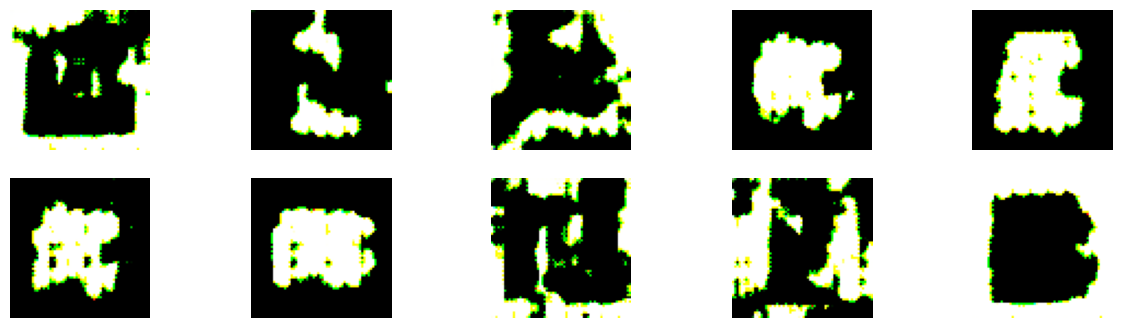

In [ ]:
import matplotlib.pyplot as plt

ruido = np.random.normal(
    size=(10,latent_dim)
)

imagenes_generadas = decoder.predict(ruido)

plt.figure(figsize=(15,4))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(imagenes_generadas[i])

    plt.axis("off")

plt.show()

Configurar rutas deepsep

In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/mi_proyecto_pokemon"
CARPETA_IMAGENES = os.path.join(BASE_DIR, "datos_procesados")
ARCHIVO_CSV = os.path.join(BASE_DIR, "metadata", "etiquetas_pokemon.csv")

print("📂 Verificando rutas:")
print(f"📁 Imágenes: {CARPETA_IMAGENES} -> {os.path.exists(CARPETA_IMAGENES)}")
print(f"📄 CSV: {ARCHIVO_CSV} -> {os.path.exists(ARCHIVO_CSV)}")

# Si el CSV reducido no existe, lo generamos desde el original
if not os.path.exists(ARCHIVO_CSV):
    print("⚠️ El CSV reducido no se encuentra. Generándolo...")
    archivo_original = os.path.join(BASE_DIR, "metadata", "etiquetas_pokemon.csv")
    if os.path.exists(archivo_original):
        import pandas as pd
        columnas_seleccionadas = [
            'nombre_archivo',
            'postura_bipedo', 'postura_cuadrupedo', 'postura_serpentiforme', 'postura_volador',
            'ojos_circulares', 'ojos_rasgados', 'sin_ojos',
            'delantera_brazo', 'delantera_pata', 'delantera_ala', 'sin_delantera',
            'trasera_pata_animal', 'trasera_pata_ave', 'sin_trasera',
            'cola_larga_flexible', 'cola_maza', 'sin_cola',
            'nivel_evolutivo'
        ]
        df = pd.read_csv(archivo_original)
        columnas_existentes = [col for col in columnas_seleccionadas if col in df.columns]
        df_nuevo = df[columnas_existentes].copy()
        df_nuevo.to_csv(ARCHIVO_CSV, index=False)
        print(f"✅ CSV reducido generado en: {ARCHIVO_CSV}")
    else:
        print("❌ No se encontró el CSV original. Sube el reducido manualmente.")

📂 Verificando rutas:
📁 Imágenes: /content/drive/MyDrive/mi_proyecto_pokemon/datos_procesados -> False
📄 CSV: /content/drive/MyDrive/mi_proyecto_pokemon/metadata/etiquetas_pokemon.csv -> False
⚠️ El CSV reducido no se encuentra. Generándolo...
❌ No se encontró el CSV original. Sube el reducido manualmente.


CONFIGURACIÓN DE ENTRENAMIENTO

🚀 Dispositivo: cpu
📊 240 Pokémon, 18 características.
📋 Columnas: ['postura_bipedo', 'postura_cuadrupedo', 'postura_serpentiforme', 'postura_volador', 'ojos_circulares', 'ojos_rasgados', 'sin_ojos', 'delantera_brazo', 'delantera_pata', 'delantera_ala', 'sin_delantera', 'trasera_pata_animal', 'trasera_pata_ave', 'sin_trasera', 'cola_larga_flexible', 'cola_maza', 'sin_cola', 'nivel_evolutivo']
🎯 Modelos listos. Entrenando con 18 características.
Época [10/500]  D_loss: 0.6859  G_loss: 1.8566
Época [20/500]  D_loss: 1.2407  G_loss: 0.9123
Época [30/500]  D_loss: 0.9214  G_loss: 1.1922
Época [40/500]  D_loss: 0.9234  G_loss: 1.0962
Época [50/500]  D_loss: 0.8757  G_loss: 1.4578
Época [60/500]  D_loss: 0.9261  G_loss: 1.1011
Época [70/500]  D_loss: 1.0032  G_loss: 0.9377
Época [80/500]  D_loss: 0.9064  G_loss: 1.0314
Época [90/500]  D_loss: 1.0107  G_loss: 1.2077
Época [100/500]  D_loss: 1.0819  G_loss: 1.6030
Época [110/500]  D_loss: 1.0120  G_loss: 1.0905
Época [120/500]  D_loss: 1.1128  

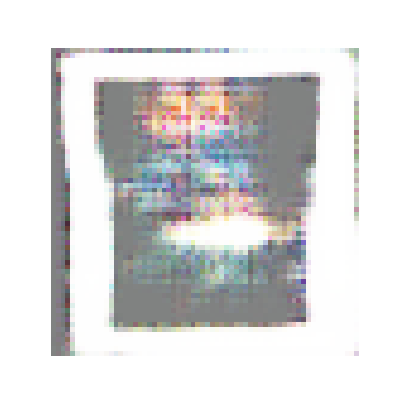

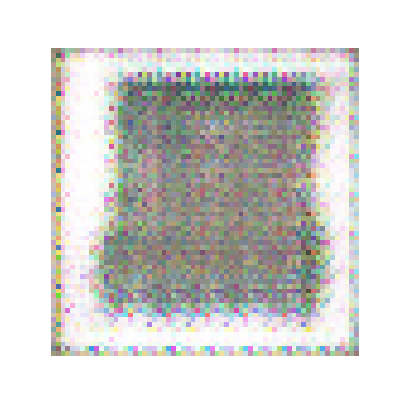

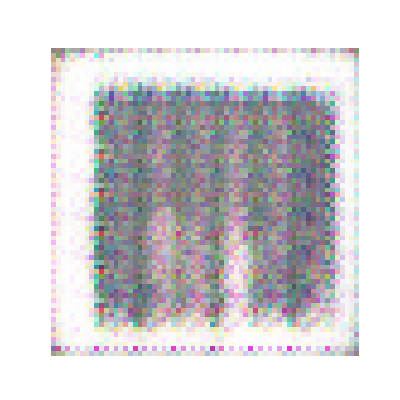

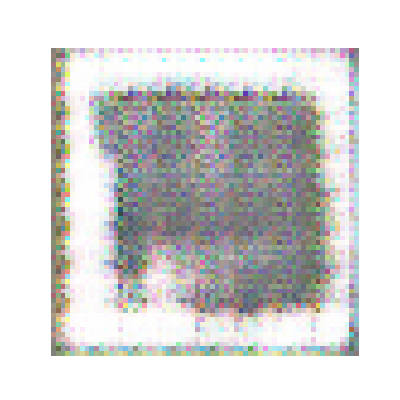

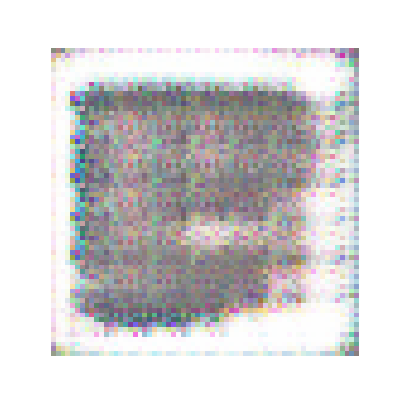

In [ ]:
# ============================================================
# ENTRENAMIENTO GAN - DATASET REDUCIDO (18 CARACTERÍSTICAS) + SN
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
import torchvision.transforms as transforms
from torch.nn.utils import spectral_norm
warnings.filterwarnings("ignore")

# ============================================================
# 1. CONFIGURACIÓN (rutas absolutas)
# ============================================================
BASE_DIR = "/content/drive/MyDrive/mi_proyecto_pokemon"
CARPETA_IMAGENES = os.path.join(BASE_DIR, "datos_procesados")
ARCHIVO_CSV = os.path.join(BASE_DIR, "metadata", "etiquetas_pokemon_reducido.csv")
CARPETA_SALIDA = os.path.join(BASE_DIR, "salidas_18_sn")

os.makedirs(CARPETA_SALIDA, exist_ok=True)

# ============================================================
# 2. HIPERPARÁMETROS (ajustados para ~18 características)
# ============================================================
BATCH_SIZE = 32
LATENT_DIM = 200          # <--- AUMENTADO (más ruido)
NUM_EPOCHS = 500          # <--- AUMENTADO (más tiempo)
LEARNING_RATE = 0.0001    # <--- REDUCIDO (más estable)
BETA1 = 0.5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Dispositivo: {DEVICE}")

# ============================================================
# 3. DATASET CON DATA AUGMENTATION
# ============================================================
class PokemonDataset(Dataset):
    def __init__(self, carpeta_imagenes, archivo_csv):
        self.df = pd.read_csv(archivo_csv)
        self.carpeta = carpeta_imagenes
        self.cols_caracteristicas = [c for c in self.df.columns if c != 'nombre_archivo']
        self.num_caracteristicas = len(self.cols_caracteristicas)
        print(f"📊 {len(self.df)} Pokémon, {self.num_caracteristicas} características.")
        print(f"📋 Columnas: {self.cols_caracteristicas}")

        self.augment = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomAffine(degrees=5, translate=(0.05, 0.05)),
            transforms.ColorJitter(brightness=0.1, contrast=0.1)
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        nombre = self.df.iloc[idx]['nombre_archivo']
        ruta = os.path.join(self.carpeta, nombre)
        imagen = torch.tensor(np.load(ruta), dtype=torch.float32).permute(2, 0, 1)
        imagen = self.augment(imagen)
        caracteristicas = self.df.iloc[idx][self.cols_caracteristicas].values.astype(np.float32)
        caracteristicas = torch.tensor(caracteristicas, dtype=torch.float32)
        return imagen, caracteristicas

# ============================================================
# 4. GENERADOR
# ============================================================
class Generator(nn.Module):
    def __init__(self, latent_dim, num_condiciones):
        super(Generator, self).__init__()
        self.fc = nn.Linear(latent_dim + num_condiciones, 256 * 4 * 4)
        self.deconv1 = nn.ConvTranspose2d(256, 128, 4, 2, 1)
        self.deconv2 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.deconv3 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.deconv4 = nn.ConvTranspose2d(32, 3, 4, 2, 1)
        self.bn1 = nn.BatchNorm2d(128)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(True)
        self.tanh = nn.Tanh()

    def forward(self, z, condiciones):
        x = torch.cat([z, condiciones], dim=1)
        x = self.fc(x)
        x = x.view(-1, 256, 4, 4)
        x = self.relu(self.bn1(self.deconv1(x)))
        x = self.relu(self.bn2(self.deconv2(x)))
        x = self.relu(self.bn3(self.deconv3(x)))
        x = self.tanh(self.deconv4(x))
        return x

# ============================================================
# 5. DISCRIMINADOR CON SPECTRAL NORMALIZATION
# ============================================================
class DiscriminatorSN(nn.Module):
    def __init__(self, num_condiciones):
        super(DiscriminatorSN, self).__init__()
        self.conv1 = spectral_norm(nn.Conv2d(3, 32, 4, 2, 1))
        self.conv2 = spectral_norm(nn.Conv2d(32, 64, 4, 2, 1))
        self.conv3 = spectral_norm(nn.Conv2d(64, 128, 4, 2, 1))
        self.conv4 = spectral_norm(nn.Conv2d(128, 256, 4, 2, 1))
        self.leaky = nn.LeakyReLU(0.2, inplace=True)
        self.fc_img = spectral_norm(nn.Linear(256 * 4 * 4, 256))
        self.fc_cond = spectral_norm(nn.Linear(num_condiciones, 256))
        self.fc_final = spectral_norm(nn.Linear(256 + 256, 1))
        self.sigmoid = nn.Sigmoid()

    def forward(self, img, condiciones):
        x = self.leaky(self.conv1(img))
        x = self.leaky(self.conv2(x))
        x = self.leaky(self.conv3(x))
        x = self.leaky(self.conv4(x))
        x = x.view(x.size(0), -1)
        img_features = self.leaky(self.fc_img(x))
        cond_features = self.leaky(self.fc_cond(condiciones))
        combined = torch.cat([img_features, cond_features], dim=1)
        out = self.sigmoid(self.fc_final(combined))
        return out

# ============================================================
# 6. INSTANCIAR
# ============================================================
dataset = PokemonDataset(CARPETA_IMAGENES, ARCHIVO_CSV)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
num_condiciones = dataset.num_caracteristicas

netG = Generator(LATENT_DIM, num_condiciones).to(DEVICE)
netD = DiscriminatorSN(num_condiciones).to(DEVICE)

criterion = nn.BCELoss()
optimizerG = optim.Adam(netG.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))

print(f"🎯 Modelos listos. Entrenando con {num_condiciones} características.")

# ============================================================
# 7. ENTRENAMIENTO
# ============================================================
for epoch in range(NUM_EPOCHS):
    for i, (imagenes_reales, condiciones) in enumerate(dataloader):
        batch_size = imagenes_reales.size(0)
        imagenes_reales = imagenes_reales.to(DEVICE)
        condiciones = condiciones.to(DEVICE)

        real_labels = torch.ones(batch_size, 1).to(DEVICE) * 0.9
        fake_labels = torch.zeros(batch_size, 1).to(DEVICE) + 0.1

        # --- Discriminador ---
        output_real = netD(imagenes_reales, condiciones)
        loss_real = criterion(output_real, real_labels)

        z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
        imagenes_falsas = netG(z, condiciones)
        output_fake = netD(imagenes_falsas.detach(), condiciones)
        loss_fake = criterion(output_fake, fake_labels)

        lossD = loss_real + loss_fake
        netD.zero_grad()
        lossD.backward()
        optimizerD.step()

        # --- Generador ---
        z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
        imagenes_falsas = netG(z, condiciones)
        output = netD(imagenes_falsas, condiciones)
        lossG = criterion(output, real_labels)

        netG.zero_grad()
        lossG.backward()
        optimizerG.step()

    if (epoch + 1) % 10 == 0:
        print(f"Época [{epoch+1}/{NUM_EPOCHS}]  D_loss: {lossD.item():.4f}  G_loss: {lossG.item():.4f}")
        with torch.no_grad():
            z_fijo = torch.randn(1, LATENT_DIM).to(DEVICE)
            cond_fija = dataset[0][1].unsqueeze(0).to(DEVICE)
            img = netG(z_fijo, cond_fija).cpu().numpy().squeeze().transpose(1, 2, 0)
            img = (img + 1) / 2
            img = np.clip(img, 0, 1)
            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            plt.axis('off')
            plt.savefig(os.path.join(CARPETA_SALIDA, f"epoca_{epoch+1}.png"))
            plt.close()

print("🎉 ¡Entrenamiento completado!")

# ============================================================
# 8. GUARDAR MODELO
# ============================================================
nombre_modelo = f"generador_{num_condiciones}car_{NUM_EPOCHS}ep.pth"
ruta_modelo = os.path.join(BASE_DIR, nombre_modelo)
torch.save(netG.state_dict(), ruta_modelo)
print(f"✅ Modelo guardado en: {ruta_modelo}")

# ============================================================
# 9. VISUALIZACIÓN FINAL
# ============================================================
import glob
from IPython.display import Image as IPImage, display

imagenes_generadas = sorted(glob.glob(os.path.join(CARPETA_SALIDA, "*.png")))
print(f"\n📸 Se generaron {len(imagenes_generadas)} imágenes.")
print("🖼️ Mostrando las últimas 5:\n")
for ruta in imagenes_generadas[-5:]:
    display(IPImage(ruta, width=256, height=256))

otro codigo

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# ============================================================
# CONFIGURACIÓN
# ============================================================
BASE_DIR = "/content/drive/MyDrive/mi_proyecto_pokemon"
ruta_modelo = os.path.join(BASE_DIR, "generador_18car_300ep.pth")  # El que acabas de entrenar
archivo_csv = os.path.join(BASE_DIR, "metadata", "etiquetas_pokemon_reducido.csv")

LATENT_DIM = 128  # <--- ¡DEBE COINCIDIR CON EL ENTRENAMIENTO!
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 1. Cargar el CSV para saber el número de características
# ============================================================
df = pd.read_csv(archivo_csv)
columnas_caracteristicas = [c for c in df.columns if c != 'nombre_archivo']
NUM_CONDICIONES = len(columnas_caracteristicas)
print(f"📊 CSV tiene {NUM_CONDICIONES} características.")
print(f"📋 Columnas: {columnas_caracteristicas}")

# ============================================================
# 2. Definir el Generador (con el número correcto y LATENT_DIM=128)
# ============================================================
class Generator(nn.Module):
    def __init__(self, latent_dim, num_condiciones):
        super(Generator, self).__init__()
        self.fc = nn.Linear(latent_dim + num_condiciones, 256 * 4 * 4)
        self.deconv1 = nn.ConvTranspose2d(256, 128, 4, 2, 1)
        self.deconv2 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.deconv3 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.deconv4 = nn.ConvTranspose2d(32, 3, 4, 2, 1)
        self.bn1 = nn.BatchNorm2d(128)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(True)
        self.tanh = nn.Tanh()

    def forward(self, z, condiciones):
        x = torch.cat([z, condiciones], dim=1)
        x = self.fc(x)
        x = x.view(-1, 256, 4, 4)
        x = self.relu(self.bn1(self.deconv1(x)))
        x = self.relu(self.bn2(self.deconv2(x)))
        x = self.relu(self.bn3(self.deconv3(x)))
        x = self.tanh(self.deconv4(x))
        return x

# ============================================================
# 3. Cargar el modelo
# ============================================================
netG = Generator(LATENT_DIM, NUM_CONDICIONES).to(DEVICE)
netG.load_state_dict(torch.load(ruta_modelo, map_location=DEVICE))
netG.eval()
print("✅ Modelo cargado correctamente.")

# ============================================================
# 4. Función para generar imágenes
# ============================================================
def generar_monstruo(condiciones, netG, latent_dim=LATENT_DIM):
    with torch.no_grad():
        z = torch.randn(1, latent_dim).to(DEVICE)
        cond = torch.tensor(condiciones, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        img = netG(z, cond).cpu().numpy().squeeze().transpose(1, 2, 0)
        img = (img + 1) / 2
        img = np.clip(img, 0, 1)
    return img

# ============================================================
# 5. Ejemplo: Crear un vector de condiciones (18 características)
# ============================================================
cond_ejemplo = [0] * NUM_CONDICIONES

# Activar algunas características (usa los nombres de columna)
if 'postura_bipedo' in columnas_caracteristicas:
    cond_ejemplo[columnas_caracteristicas.index('postura_bipedo')] = 1
if 'ojos_circulares' in columnas_caracteristicas:
    cond_ejemplo[columnas_caracteristicas.index('ojos_circulares')] = 1
if 'sin_cola' in columnas_caracteristicas:
    cond_ejemplo[columnas_caracteristicas.index('sin_cola')] = 1
if 'nivel_evolutivo' in columnas_caracteristicas:
    cond_ejemplo[columnas_caracteristicas.index('nivel_evolutivo')] = 1

print("🔧 Vector de condiciones de ejemplo:", cond_ejemplo)

# ============================================================
# 6. Generar y mostrar
# ============================================================
img = generar_monstruo(cond_ejemplo, netG)
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis('off')
plt.title("Monstruo generado (18 características)")
plt.show()

# Generar varias variaciones
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    img_var = generar_monstruo(cond_ejemplo, netG)
    ax.imshow(img_var)
    ax.axis('off')
    ax.set_title(f"Var {i+1}")
plt.suptitle("Variaciones con el mismo vector de condiciones")
plt.show()

📊 CSV tiene 18 características.
📋 Columnas: ['postura_bipedo', 'postura_cuadrupedo', 'postura_serpentiforme', 'postura_volador', 'ojos_circulares', 'ojos_rasgados', 'sin_ojos', 'delantera_brazo', 'delantera_pata', 'delantera_ala', 'sin_delantera', 'trasera_pata_animal', 'trasera_pata_ave', 'sin_trasera', 'cola_larga_flexible', 'cola_maza', 'sin_cola', 'nivel_evolutivo']


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/mi_proyecto_pokemon/generador_18car_300ep.pth'